# 24RB1003 松澤颯斗

# 演習１：ソフトマージンSVMの実装

### step 1 (データの生成)

In [80]:
import numpy as np
import matplotlib.pyplot as plt

In [81]:
# 平均0、分散1のの二次元ガウス分布 N(0, I) からサンプリング
# (1, 1)だけシフトしたものをクラス +1
data_plus = np.random.randn(100, 2) + 1  

# (-1, -1)だけシフトしたものをクラス -1
data_minus = np.random.randn(100, 2) - 1

In [82]:
# 正解ラベルを作る
labels_plus = np.ones(100)  # クラス +1 のラベル

labels_minus = -np.ones(100)  # クラス -1 のラベル

In [83]:
# 1つのデータセットにまとめる
X = np.vstack((data_plus, data_minus))  # データを縦に結合
y = np.hstack((labels_plus, labels_minus))  # ラベルを横に結合

In [84]:
X.shape, y.shape

((200, 2), (200,))

### step 2 (ロス関数)

In [85]:
# データ{(xi, yi)}, 重み(w, b), ハイパーパラメータCを引数に,ソフトマージンロスL(w, b)を返す関数を定義
def soft_margin_loss(X, y, w, b, C):
    loss = 0.5 * np.sum(w ** 2)  # 正則化項
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]
        margin = yi * (np.dot(w, xi) + b)  # マージンの計算
        loss += C * max(0, 1 - margin)  # ヒンジ損失の計算
    return loss

### step 3 (勾配)

In [86]:
# 勾配∇wL(w, b)と∇bL(w, b)を計算する関数を定義
def soft_margin_loss_grad(X, y, w, b, C):
    grad_w = w.copy()  # 正則化項の勾配
    grad_b = 0         # バイアスの勾配
    for i in range(len(X)):
        margin = y[i] * (np.dot(w, X[i]) + b)
        if margin < 1:  # ヒンジ損失が発生している場合
            grad_w -= C * y[i] * X[i]
            grad_b -= C * y[i]
    return grad_w, grad_b

### step4 (勾配法)

In [87]:
# soft_margin_loss_grad関数を用いて、最適なwとbを勾配降下法で求める
def train_svm(X, y, C, learning_rate=0.001, num_epoch=100):
    w = np.zeros(X.shape[1])
    # w = np.array([2.0, -2.0])
    b = 0
    losses = []
    boundary_history = []

    for epoch in range(num_epoch):
        # 現在のロスを記録
        losses.append(soft_margin_loss(X, y, w, b, C))

        # 初期(5)・中期(50)・最終(99)の (w, b) を記録
        if epoch in [5, num_epoch//2, num_epoch-1]:
            boundary_history.append((w.copy(), b))

        # 勾配を計算して更新
        grad_w, grad_b = soft_margin_loss_grad(X, y, w, b, C)
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w, b, losses, boundary_history

In [88]:
# 学習の実行 
w, b, losses, boundary_history = train_svm(X, y, C=1.0, learning_rate=0.001, num_epoch=100)

### step5 (可視化)

##### 損失曲線

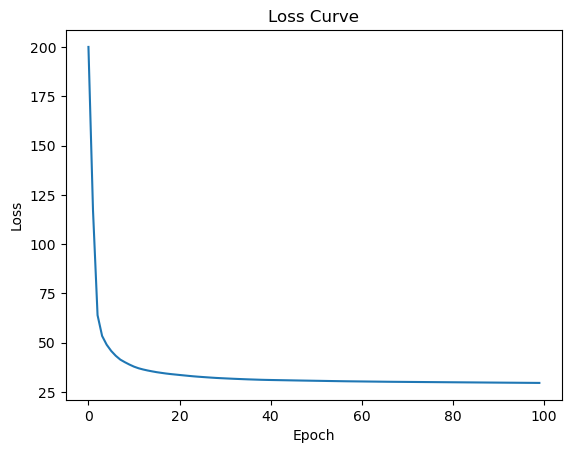

In [89]:
# ロスの推移をプロット
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

##### 境界の推移

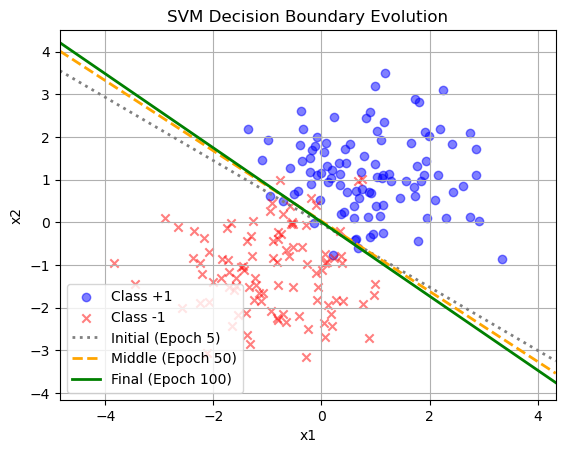

In [90]:
# 決定境界の推移をプロット
plt.scatter(data_plus[:, 0], data_plus[:, 1], c='blue', marker='o', label='Class +1', alpha=0.5)
plt.scatter(data_minus[:, 0], data_minus[:, 1], c='red', marker='x', label='Class -1', alpha=0.5)

x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
legend_labels = ['Initial (Epoch 5)', 'Middle (Epoch 50)', 'Final (Epoch 100)']
colors = ['gray', 'orange', 'green']
linestyles = [':', '--', '-']

for i, (w_hist, b_hist) in enumerate(boundary_history):
    x2_vals = -(w_hist[0] * x1_vals + b_hist) / w_hist[1]
    plt.plot(x1_vals, x2_vals, label=legend_labels[i], color=colors[i], linestyle=linestyles[i], linewidth=2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM Decision Boundary Evolution')
plt.legend()
plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.grid()
plt.show()

# 演習２：特徴抽出 + ソフトマージンSVM

### Step1 (データ生成)

In [91]:
#二重同心円のデータセットをつくる

# データ数
n_samples = 100
 
# 0 から 2π の範囲でランダムな角度θを生成
theta_in = np.random.uniform(0, 2 * np.pi, n_samples)
theta_out = np.random.uniform(0, 2 * np.pi, n_samples)

# 半径の設定
r_in = 1.0  # 内側（クラス +1）
r_out = 3.0 # 外側（クラス -1）

In [92]:
# 内側の円のデータ（クラス +1）
x1_in = r_in * np.cos(theta_in)
x2_in = r_in * np.sin(theta_in)

# 外側の円のデータ（クラス -1）
x1_out = r_out * np.cos(theta_out)
x2_out = r_out * np.sin(theta_out)

In [93]:
# ノイズを追加
noise_level = 0.3

# 内側の円にノイズを追加
x1_in += noise_level * np.random.randn(n_samples)
x2_in += noise_level * np.random.randn(n_samples)

# 外側の円にノイズを追加
x1_out += noise_level * np.random.randn(n_samples)
x2_out += noise_level * np.random.randn(n_samples)

In [94]:
# (x1, x2) をまとめて (100, 2) の配列にする
data_in = np.column_stack((x1_in, x2_in))
data_out = np.column_stack((x1_out, x2_out))

In [95]:
# 正解ラベルを作る
labels_in = np.ones(100)  # クラス +1 のラベル
labels_out = -np.ones(100)  # クラス -1 のラベル

In [96]:
# 1つのデータセットにまとめる
X = np.vstack((data_in, data_out))  # データを縦に結合
y = np.hstack((labels_in, labels_out))  # ラベルを横に結合

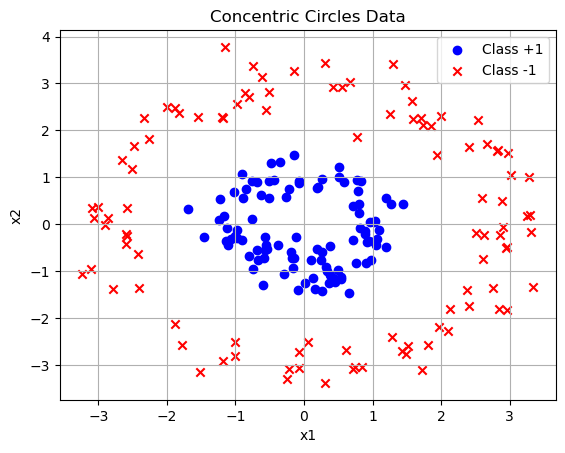

In [97]:
# 内側のデータ（クラス +1）を青色の丸でプロット
plt.scatter(data_in[:, 0], data_in[:, 1], color='blue', marker='o', label='Class +1')
# 外側のデータ（クラス -1）を赤色のバツでプロット
plt.scatter(data_out[:, 0], data_out[:, 1], color='red', marker='x', label='Class -1')

plt.title("Concentric Circles Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

### Step2 (特徴抽出)

In [98]:
# 既定関数 φ(x) を定義
def phi(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    x3 = x1**2 + x2**2
    return np.column_stack((x1, x2, x3))

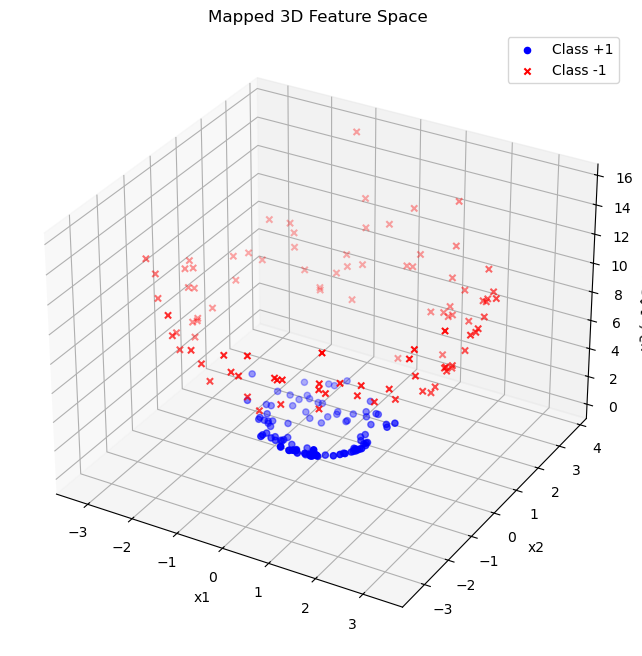

In [99]:
# 特徴抽出を実行して3次元データ X_phi に変換
X_phi = phi(X)

# 3Dプロット
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')  # 3Dグラフを指定

# 内側のデータ(クラス+1)は最初の100個、外側のデータ(クラス-1)は次の100個
ax.scatter(X_phi[:100, 0], X_phi[:100, 1], X_phi[:100, 2], c='blue', marker='o', label='Class +1')
ax.scatter(X_phi[100:, 0], X_phi[100:, 1], X_phi[100:, 2], c='red', marker='x', label='Class -1')

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3 (x1^2 + x2^2)')
ax.set_title('Mapped 3D Feature Space')
plt.legend()
plt.show()

### Step3-5 (学習)

In [100]:
# 学習の実行
w, b, losses, boundary_history = train_svm(phi(X), y, C=1.0, learning_rate=0.001, num_epoch=100)

### Step6 (可視化)

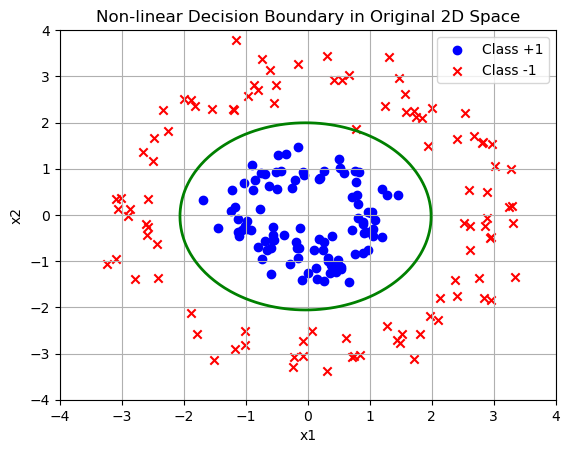

In [101]:
# 元の2次元データをプロット
plt.scatter(data_in[:, 0], data_in[:, 1], color='blue', marker='o', label='Class +1')
plt.scatter(data_out[:, 0], data_out[:, 1], color='red', marker='x', label='Class -1')

# グラフに線を引くためのメッシュを作成
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)

# w1*x1 + w2*x2 + w3*(x1^2 + x2^2) + b
Z = w[0]*x[:, np.newaxis] + w[1]*y[np.newaxis, :] + w[2]*(x[:, np.newaxis]**2 + y[np.newaxis, :]**2) + b

# Z = 0 となる場所（境界線）に緑色の線を引く
plt.contour(x, y, Z, levels=[0], colors='green', linewidths=2)

plt.title('Non-linear Decision Boundary in Original 2D Space')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

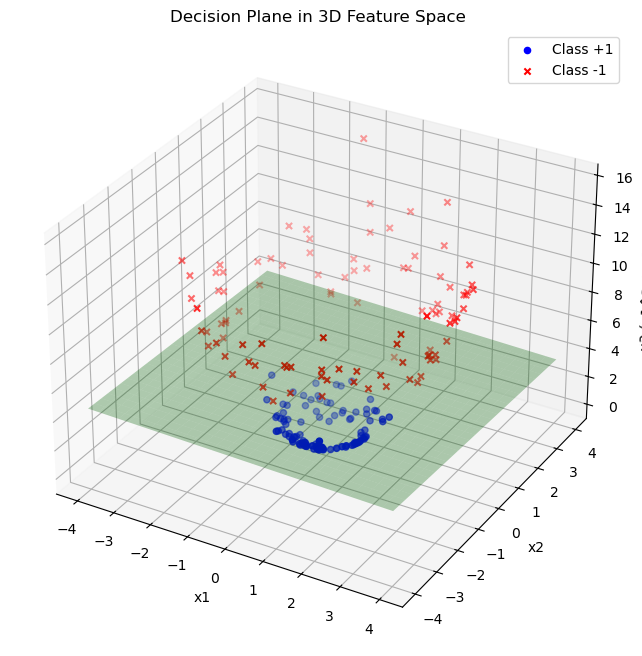

In [102]:
# 3Dプロット
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# データのプロット 
ax.scatter(X_phi[:100, 0], X_phi[:100, 1], X_phi[:100, 2], c='blue', marker='o', label='Class +1')
ax.scatter(X_phi[100:, 0], X_phi[100:, 1], X_phi[100:, 2], c='red', marker='x', label='Class -1')

# 平面を描くためのメッシュ (x1, x2) を作成
x1_mesh, x2_mesh = np.meshgrid(np.linspace(-4, 4, 30), np.linspace(-4, 4, 30))

# x3 を計算
x3_plane = -(w[0] * x1_mesh + w[1] * x2_mesh + b) / w[2]

# 平面を半透明の緑色でプロット
ax.plot_surface(x1_mesh, x2_mesh, x3_plane, color='green', alpha=0.3)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3 (x1^2 + x2^2)')
ax.set_title('Decision Plane in 3D Feature Space')
plt.legend()
plt.show()

# 考察

演習1で学習過程における損失関数の推移を観察した結果，学習の初期段階において損失が急激に減少し，その後は一定の値に収束した．すなわち，初期エポックの段階においてすでに最適境界に近い位置までパラメータが更新され，中盤以降はマージン最大化に向けた調整が行われていたと考えられる．また，$w$ の初期値を意図的に乖離させた値（$w = [2.0, -2.0]$）に設定した場合においても，エポックの経過に伴い最適な境界線へと軌道修正されていった．  
演習2では，特徴抽出関数 $\phi(x) = (x_1, x_2, x_1^2 + x_2^2)$ を用いて2次元データを3次元空間へ写像した．可視化の結果，原点からの距離の2乗（$x_3$）という新たな次元が加わることでデータが放物面状に配置され，単一の平面により完全に線形分離可能となった．さらに，3次元空間の学習で得られた決定平面の方程式 $w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 0$ に対し，$x_3 = x_1^2 + x_2^2$ を代入することで，元の2次元空間における境界線が「円の方程式」となり，2次元平面上にプロットした結果，両クラスを分割する円形の境界線が描画された．

# AI使用について

Gemini Guided Learningを使用して，データの生成方法や勾配降下法の実装方法について質問した．AI に直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．